# Example notebook for the wAMEs model

The wAMEs model is an approximate master equation framework introduced in *“Group dynamics drive transition shifts and multistable active phases under collectively reinforced contagion”*  by S. Lamata-Otín et al.

This notebook illustrates how to run the wAMEs model. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath("src"))

As a guiding example, we reproduce our main result, the multistable active phases shown in Fig 3. Therefore, we first import the information about the high-school structure and set the parameters. 

In [2]:
from wAMEs.core import load_group_statistics

# Load group statistics
network = "Thiers13"
gm, pn, mmax, nmax, pmax, state_meta = load_group_statistics(
    network,
    path="Data/group_statistics.txt",
)

# Model parameters
nu = 9.5
mu = 1.0
w = 5.0

# Output directory
save_dir = "Files"
os.makedirs(save_dir, exist_ok=True)

# Dynamical trajectories:

In [3]:
from wAMEs.temporal_dynamics import integrate_I_traj
from wAMEs.plotting import get_plot_style, make_truncated_colormap, apply_axis_style
from matplotlib.colors import LogNorm

The following cell computes trajectories by integrating Eqs. (7)-(11) for the representative case $(\lambda,\nu,\omega)=(2\times 10^{-3},9.5,5)$, and  a range of initial conditions. Then, it stores the results in a compressed `.npz` file.

In [ ]:
# Integration settings
traj_points = 100000
t_max = None
initial_conditions = np.logspace(-2, np.log10(0.99), 101)

# Transmission rate(s)
lam_array = np.array([2e-3], dtype=float)

# Compute trajectories
all_t = []
all_I = []
all_lam = []
all_I0 = []
stationary_values = {}

for lam in lam_array:
    for I0 in initial_conditions:
        t, I_t = integrate_I_traj(
            lam=lam,
            state_meta=state_meta,
            nmax=nmax,
            mmax=mmax,
            gm=gm,
            mu=mu,
            w=w,
            nu=nu,
            I0=I0,
            traj_points=traj_points,
            t_max=t_max,
        )

        all_t.append(np.asarray(t, dtype=float))
        all_I.append(np.asarray(I_t, dtype=float))
        all_lam.append(float(lam))
        all_I0.append(float(I0))

        stationary_values[(float(lam), float(I0))] = float(I_t[-1])

# Save results
outpath = os.path.join(save_dir, "traj_case_lam2e-3_nu9p5_w5.npz")

np.savez_compressed(
    outpath,
    lam_array=np.asarray(all_lam, dtype=float),
    I0_array=np.asarray(all_I0, dtype=float),
    t_list=np.array(all_t, dtype=object),
    I_list=np.array(all_I, dtype=object),
    nu=float(nu),
    mu=float(mu),
    w=float(w),
    traj_points=int(traj_points),
)

print(f"Saved results to: {outpath}")

Saved results to: Files/traj_case_lam2e-3_nu9p5_w5.npz


In [ ]:
print()

In [5]:
print(all_I0)

[0.01, 0.01047023313403309, 0.010962578188100433, 0.011478074937947759, 0.012017812053021543, 0.012582929395612839, 0.013174620428114445, 0.013794134733475308, 0.014442780654174987, 0.015121928055291506, 0.01583301121749776, 0.016577531866096267, 0.017357062342489054, 0.01817324892478068, 0.01902781530452699, 0.01992256622697204, 0.020859391302461127, 0.021840268997079016, 0.022867270810941222, 0.02394256565296245, 0.025068424421341006, 0.026247224799432877, 0.027481456277143716, 0.028773725408443175, 0.030126761316105154, 0.03154342145529904, 0.03302669764820423, 0.034579722402392064, 0.03620577552631915, 0.03790829105590311, 0.0396908645068087, 0.04155726046776064, 0.04351142055091909, 0.04555747171610812, 0.04769973498647705, 0.049942734574000926, 0.05229120743409244, 0.054750113269503214, 0.05732464500464173, 0.060020239752428435, 0.06284259029684862, 0.06579765711545305, 0.06889168096719646, 0.07213119607219767, 0.07552304391125617, 0.07907438767426703, 0.08279272738804884, 0.0866

The following cell loads the previously computed trajectories and plots them, with colors encoding the initial condition $I_0$.

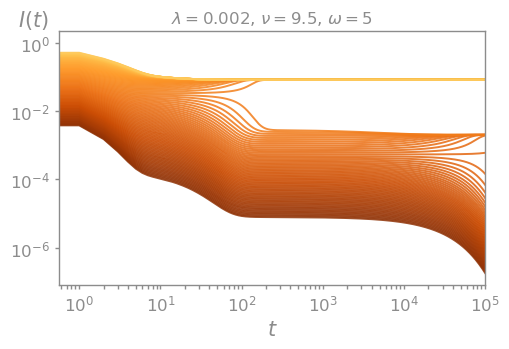

In [6]:
style = get_plot_style()

path = os.path.join(save_dir, "traj_case_lam2e-3_nu9p5_w5.npz")
dat = np.load(path, allow_pickle=True)

lam_vals = dat["lam_array"].astype(float)
I0_vals = dat["I0_array"].astype(float)
t_list = dat["t_list"]
I_list = dat["I_list"]

nu = float(dat["nu"])
mu = float(dat["mu"])
w = float(dat["w"])

cmap = make_truncated_colormap("YlOrBr_r", 0.1, 0.65)
norm = LogNorm(vmin=np.min(I0_vals), vmax=np.max(I0_vals))

lam_target = 2e-3
mask = np.isclose(lam_vals, lam_target)

fig, ax = plt.subplots(figsize=(5.2, 3.6))

for t, I_t, I0 in zip(t_list[mask], I_list[mask], I0_vals[mask]):
    ax.plot(
        np.asarray(t, dtype=float),
        np.asarray(I_t, dtype=float),
        lw=1.4,
        alpha=0.85,
        color=cmap(norm(I0)),
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(right=1e5)

ax.set_xlabel(r"$t$", fontsize=style["axis_labelsize"], color=style["gray"])
ax.set_ylabel(r"$I(t)$", fontsize=style["axis_labelsize"], color=style["gray"], rotation=0)
ax.yaxis.set_label_coords(-0.06, 1)

ax.set_title(
    rf"$\lambda={lam_target:.3g}$, $\nu={nu:g}$, $\omega={w:g}$",
    fontsize=12,
    color=style["gray"],
)

apply_axis_style(ax, style)
plt.tight_layout()
plt.show()

# Stationary states:

In [7]:
from wAMEs.fixed_points import normalize_group_distribution, collect_fixed_points_by_lam, pack_per_lam_pts, unpack_per_lam_pts, plot_rank_tracked_branches, add_break_marks, format_x_axis_times10
from wAMEs.plotting import get_plot_style, apply_axis_style, add_log_minor_ticks, AutoMinorLocator
from matplotlib.colors import Normalize

The following cell computes the stationary states of the wAME system by solving the stationary implicit relation in Eqs. (12)-(13) for a range of transmission rates at fixed $\nu$ and $\omega$, and stores the resulting branches for later visualization.

In [8]:
m_arr = np.arange(mmax + 1, dtype=float)
pn_normalized = normalize_group_distribution(pn, nmin=2)

# Case to compute
case = dict(
    name="case1_lam_1p8e-3_2p8e-3_nu9p5",
    lam_array=np.logspace(np.log10(1.7e-3), np.log10(2.9e-3), 201),
    nu=9.5,
)

# Numerical parameters for root finding
r_min = 1e-12
r_max = 10.0
n_grid_root = 4000

# Compute stationary branches
name = case["name"]
lam_vals = case["lam_array"]
nu = float(case["nu"])

per_lam_pts = collect_fixed_points_by_lam(
    lam_vals=lam_vals,
    nu=nu,
    nmax=nmax,
    mu=mu,
    w=w,
    state_meta=state_meta,
    m_arr=m_arr,
    gm=gm,
    pn_filtered=pn_normalized,
    r_min=r_min,
    r_max=r_max,
    n_grid_root=n_grid_root,
)

I, P, stable = pack_per_lam_pts(per_lam_pts, lam_vals)

# Save results
outpath = os.path.join(save_dir, f"{name}.npz")
np.savez_compressed(
    outpath,
    name=name,
    nu=nu,
    lam=lam_vals.astype(float),
    I=I,
    P=P,
    stable=stable,
    r_min=float(r_min),
    r_max=float(r_max),
    n_grid_root=int(n_grid_root),
)

print(f"Saved results to: {outpath} (Kmax={I.shape[0]}, Nlam={I.shape[1]})")

Saved results to: Files/case1_lam_1p8e-3_2p8e-3_nu9p5.npz (Kmax=5, Nlam=201)


The following cell loads the saved stationary states and visualizes the fixed-point structure as a function of the transmission rate. The top panel shows the stationary prevalence $I^\star$, while the bottom panel shows the inverse participation ratio $P$.

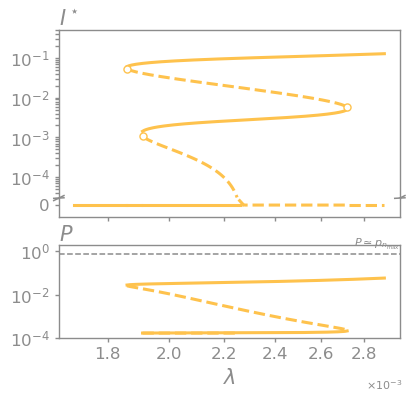

In [9]:
case_name = "case1_lam_1p8e-3_2p8e-3_nu9p5"

style = get_plot_style()
I_LOG_MIN = 3e-5
I_FLOOR = 3e-5
MARK_Y_MIN = 5e-4

cmap = make_truncated_colormap("YlOrBr_r", 0.1, 0.65)
norm = Normalize(vmin=1, vmax=10)

path = os.path.join(save_dir, f"{case_name}.npz")
dat = np.load(path, allow_pickle=False)

nu = float(dat["nu"])
lam_vals = dat["lam"].astype(float)
I = dat["I"].astype(float)
P = dat["P"].astype(float)
stable = dat["stable"].astype(np.int8)

per_lam_pts = unpack_per_lam_pts(lam_vals, I, P, stable)
panel_color = cmap(norm(nu))

fig = plt.figure(figsize=(4.4, 4.0))
sub = fig.add_gridspec(2, 1, height_ratios=[2, 1.0], hspace=0.2)
top = sub[0, 0].subgridspec(2, 1, height_ratios=[0.9, 0.1], hspace=0)

ax_log = fig.add_subplot(top[0, 0])
ax_lin = fig.add_subplot(top[1, 0], sharex=ax_log)
ax_bot = fig.add_subplot(sub[1, 0], sharex=ax_log)

ax_log.set_xscale("log")
ax_lin.set_xscale("log")
ax_log.set_yscale("log")
ax_bot.set_xscale("log")
ax_bot.set_yscale("log")

ax_log.set_ylim(I_LOG_MIN, 5e-1)
ax_lin.set_ylim(-5e-5, I_LOG_MIN)
ax_bot.set_ylim(1e-4, 2)

plot_rank_tracked_branches(
    ax=ax_log,
    per_lam_pts=per_lam_pts,
    ykey="I",
    y_min=I_LOG_MIN,
    color=panel_color,
    mark_unstable_extrema=True,
    marker_size=26,
    mark_y_min=MARK_Y_MIN,
)

plot_rank_tracked_branches(
    ax=ax_lin,
    per_lam_pts=per_lam_pts,
    ykey="I",
    y_min=0.0,
    y_max=I_LOG_MIN,
    color=panel_color,
    mark_unstable_extrema=True,
    marker_size=26,
    mark_y_min=MARK_Y_MIN,
)

plot_rank_tracked_branches(
    ax=ax_bot,
    per_lam_pts=per_lam_pts,
    ykey="P",
    I_filter=I_FLOOR,
    color=panel_color,
    mark_unstable_extrema=True,
    marker_size=26,
    mark_y_min=MARK_Y_MIN,
)

ax_log.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
ax_lin.tick_params(axis="x", which="both", bottom=True, labelbottom=False)

apply_axis_style(ax_log, style)
apply_axis_style(ax_lin, style)
apply_axis_style(ax_bot, style)

add_log_minor_ticks(ax_log, axis="y")
ax_lin.yaxis.set_minor_locator(AutoMinorLocator())
add_log_minor_ticks(ax_bot, axis="y")

ax_log.spines["bottom"].set_visible(False)
ax_lin.spines["top"].set_visible(False)
add_break_marks(ax_top=ax_log, ax_bot=ax_lin, color=style["gray"])
ax_lin.set_yticks([0])

ax_log.text(
    0.0, 1.0, r"$I^\star$",
    transform=ax_log.transAxes,
    ha="left", va="bottom",
    fontsize=style["axis_labelsize"],
    color=style["gray"],
)

ax_bot.axhline(pmax, color=style["gray"], linestyle="dashed", linewidth=1.1, zorder=0)
format_x_axis_times10(ax=ax_bot, color=style["gray"], fontsize=8, xpos=0.90, ypos=-0.43)

ax_bot.text(
    0.0, 1.0, r"$P$",
    transform=ax_bot.transAxes,
    ha="left", va="bottom",
    fontsize=style["axis_labelsize"],
    color=style["gray"],
)
ax_bot.set_xlabel(r"$\lambda$", fontsize=style["axis_labelsize"], color=style["gray"])

_, x1 = ax_bot.get_xlim()
ax_bot.text(
    x1,
    pmax * 1.2,
    r"$P \simeq p_{n_{\max}}$",
    fontsize=8,
    color=style["gray"],
    ha="right",
    va="bottom",
    zorder=1000,
    clip_on=False,
)

plt.show()

# Invasion and bistability thresholds:

In [10]:
from wAMEs.thresholds import find_tricritical_points_joint, tricritical_condition, invasion_threshold_w
from wAMEs. plotting import get_plot_style, make_truncated_colormap, build_colored_line_segments, apply_axis_style
from matplotlib.colors import Normalize
from matplotlib.collections import LineCollection

The following cell computes the tricritical curve in the $(\nu,\omega)$ plane by solving Eq. (15) and evaluates the invasion threshold for a representative case $(\nu,\omega)=(9.5,5)$ by solving Eq. (14).

In [11]:
# Parameters
param_min_lambda = 1e-14
param_max_lambda = 1.0

beta_template = lambda n, i, scale, shape: scale * i**shape

# Compute tricritical points
nu_tric, w_tric, lam_tric = find_tricritical_points_joint(
    tricritical_condition=tricritical_condition,
    invasion_threshold_func=invasion_threshold_w,
    beta_func=beta_template,
    mu=mu,
    gm=gm,
    pn=pn,
    lambda_min=param_min_lambda,
    lambda_max=param_max_lambda,
    w_min=1e-3,
    w_max=1e3,
    nu_min=1.0,
    nu_max=10.0,
    nu_inner_min=1.0,
    nu_inner_max=30.0,
    n_w_outer=21,
    n_nu_outer=21,
    n_w_inner=80,
    n_nu_inner=80,
)

# Compute the invasion threshold for a representative parameter choice
nu_target = 9.5
w_target = 5.0

lambda_c_target = invasion_threshold_w(
    beta=beta_template,
    w=w_target,
    mu=mu,
    gm=gm,
    pn=pn,
    fixed_args=(nu_target,),
    param_min=param_min_lambda,
    param_max=param_max_lambda,
)

# Save results
save_dir = "Files"
os.makedirs(save_dir, exist_ok=True)

np.savez(
    os.path.join(save_dir, "tricritical_points.npz"),
    nu=nu_tric,
    w=w_tric,
    lam=lam_tric,
    lambda_c_nu=np.array([nu_target], dtype=float),
    lambda_c_w=np.array([w_target], dtype=float),
    lambda_c_val=np.array([lambda_c_target], dtype=float),
)

The following cell loads the saved tricritical points and visualizes the tricritical line in the $(\lambda,\omega)$ plane, with color encoding the value of $\nu$. The invasion threshold for the representative case $(\nu,\omega)=(9.5,5)$ is also highlighted.

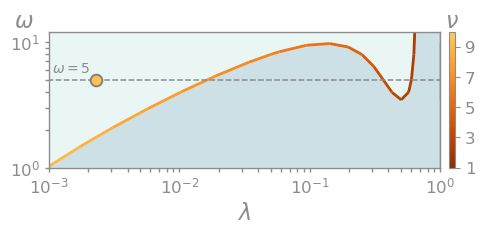

In [12]:
data = np.load("Files/tricritical_points.npz")

nu_tric = data["nu"]
w_tric = data["w"]
lam_tric = data["lam"]

lambda_c_nu = data["lambda_c_nu"]
lambda_c_w = data["lambda_c_w"]
lambda_c_val = data["lambda_c_val"]

style = get_plot_style(axis_labelsize=16)

SHADE_LIGHT = "#98D3C9"
SHADE_DARK = "#006583"
SHADE_ALPHA = 0.20

cmap = make_truncated_colormap("YlOrBr_r", 0.1, 0.65)
norm = Normalize(vmin=1, vmax=10)

nu_point = float(lambda_c_nu[0])
point_color = cmap(norm(nu_point))

fig, ax = plt.subplots(figsize=(5, 2.5))

segments = build_colored_line_segments(lam_tric, w_tric)
lc = LineCollection(segments, cmap=cmap, norm=norm, linestyle="-", linewidth=2)
lc.set_array(nu_tric[:-1])
ax.add_collection(lc)

target_w = 5.0
x_min = 1e-3
x_max = 1e0

ax.hlines(
    y=target_w,
    xmin=np.min(lam_tric),
    xmax=1e1,
    colors=style["gray"],
    linestyles="dashed",
    linewidth=1.1,
)
ax.text(
    1e-3 * 1.06,
    target_w * 1.08,
    r"$\omega=5$",
    fontsize=10,
    color=style["gray"],
    va="bottom",
)

ax.scatter(
    lambda_c_val,
    lambda_c_w,
    s=70,
    facecolor=point_color,
    edgecolor="gray",
    linewidth=1.4,
    zorder=10,
)

ax.fill_betweenx(w_tric, lam_tric, x_max, color=SHADE_DARK, alpha=SHADE_ALPHA, zorder=0)
ax.fill_betweenx(w_tric, x_min, lam_tric, color=SHADE_LIGHT, alpha=SHADE_ALPHA, zorder=0)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(x_min, x_max)
ax.set_ylim(1, 12)

apply_axis_style(ax, style)
ax.set_xlabel(r"$\lambda$", fontsize=style["axis_labelsize"], color=style["gray"])

ax.text(
    -0.065, 1.08, r"$\omega$",
    transform=ax.transAxes,
    ha="center", va="center",
    fontsize=style["axis_labelsize"],
    color=style["gray"],
)

cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.02)
cbar.ax.tick_params(labelsize=style["tick_labelsize"], colors=style["gray"])
for spine in cbar.ax.spines.values():
    spine.set_edgecolor(style["gray"])
cbar.ax.set_yticks([1, 3, 5, 7, 9])

ax.text(
    1.03, 1.08, r"$\nu$",
    transform=ax.transAxes,
    ha="center", va="center",
    fontsize=style["axis_labelsize"],
    color=style["gray"],
)

plt.tight_layout()
plt.show()

# Group-switching kernel dynamics

Instead of a scalar $\omega$, we can pass a kernel $\omega(n,i)$ that makes the switching rate depend on group size $n$ and the number of infected members $i$.

Let $\phi = i/n$ be the infected fraction within a group. Two natural kernels:

- **Allegiance** (homophily): $\omega(n,i) = \omega_0 \cdot 4\phi(1-\phi)$ — peaks at $\phi=0.5$, zero at the homogeneous extremes. Nodes flee *diverse* groups and stay in homogeneous ones.
- **Diversity-seeking**: $\omega(n,i) = \omega_0 \cdot (1 - 4\phi(1-\phi))$ — large at $\phi=0$ or $\phi=1$, zero at $\phi=0.5$. Nodes flee *homogeneous* groups and stay in mixed ones.

Both are scaled so that $\omega_0 = 5$ matches the scalar baseline used above.


ValueError: too many values to unpack (expected 2)

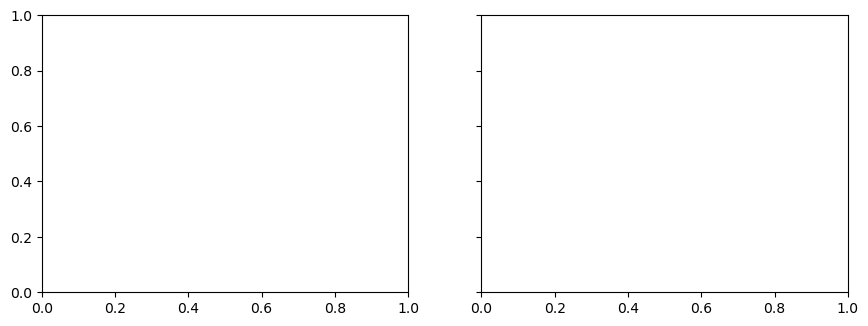

In [13]:
from wAMEs.temporal_dynamics import integrate_I_traj_kernel
from wAMEs.plotting import get_plot_style, make_truncated_colormap, apply_axis_style
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np

# --- Kernel definitions ---
# phi = i/n is the infected fraction within the group

def w_allegiance(n, i, scale):
    """Nodes flee diverse groups — prefer homogeneous ones (allegiance/homophily).
    Rate peaks at phi=0.5 and is zero at the homogeneous extremes (phi=0 or 1)."""
    phi = i / n
    return scale * 4 * phi * (1 - phi)

def w_diversity(n, i, scale):
    """Nodes flee homogeneous groups — prefer mixed ones (diversity-seeking).
    Rate is large at phi=0 or phi=1 and zero at phi=0.5."""
    phi = i / n
    return scale * (1 - 4 * phi * (1 - phi))

# --- Settings (reuse network/params loaded above) ---
traj_points = 100000
initial_conditions = np.logspace(-2, np.log10(0.99), 51)
lam_kernel = 2e-3
scale = 5.0  # omega_0 — same magnitude as the scalar w=5 baseline

kernels = {
    r"Allegiance  $\omega(n,i)=4\phi(1{-}\phi)\cdot\omega_0$": w_allegiance,
    r"Diversity  $\omega(n,i)=(1-4\phi(1{-}\phi))\cdot\omega_0$": w_diversity,
}

# --- Compute trajectories and plot ---
style = get_plot_style()
cmap = make_truncated_colormap("YlOrBr_r", 0.1, 0.65)
norm = LogNorm(vmin=np.min(initial_conditions), vmax=np.max(initial_conditions))

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.6), sharey=True)

for ax, (label, w_func) in zip(axes, kernels.items()):
    for I0 in initial_conditions:
        t, I_t = integrate_I_traj_kernel(
            lam=lam_kernel,
            w_func=w_func,
            w_args=(scale,),
            state_meta=state_meta,
            nmax=nmax,
            mmax=mmax,
            gm=gm,
            mu=mu,
            nu=nu,
            I0=I0,
            traj_points=traj_points,
        )
        ax.plot(t, I_t, lw=1.2, alpha=0.8, color=cmap(norm(I0)))

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(right=1e5)
    ax.set_xlabel(r"$t$", fontsize=style["axis_labelsize"], color=style["gray"])
    ax.set_title(label, fontsize=10, color=style["gray"])
    apply_axis_style(ax, style)

axes[0].set_ylabel(r"$I(t)$", fontsize=style["axis_labelsize"], color=style["gray"], rotation=0)
axes[0].yaxis.set_label_coords(-0.08, 1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label(r"$I_0$", fontsize=style["axis_labelsize"], color=style["gray"])
cbar.ax.tick_params(labelsize=style["tick_labelsize"], colors=style["gray"])
for spine in cbar.ax.spines.values():
    spine.set_edgecolor(style["gray"])

fig.suptitle(
    rf"$\lambda={lam_kernel:.3g}$, $\nu={nu:g}$, $\omega_0={scale:g}$ — kernel switching",
    fontsize=11, color=style["gray"], y=1.02,
)

plt.tight_layout()
plt.show()
